# Getting Started with Financial Data using Yahoo Finance

This notebook introduces how to download stock data using Yahoo Finance and perform basic analysis useful for Reinforcement Learning in trading.

## 1. Installing Required Libraries

In [42]:
!pip install yfinance


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importing Libraries

In [43]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)

## 3. Downloading Stock Data

In [44]:
ticker = 'AAPL'
data = yf.download(ticker, start='2022-01-01', end='2024-01-01', auto_adjust=False)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2022-01-03,178.270294,182.009995,182.880005,177.710007,177.830002,104487900
2022-01-04,176.007828,179.699997,182.940002,179.119995,182.630005,99310400
2022-01-05,171.326019,174.919998,180.169998,174.639999,179.610001,94537600
2022-01-06,168.465958,172.000000,175.300003,171.639999,172.699997,96904000
2022-01-07,168.632492,172.169998,174.139999,171.029999,172.889999,86709100


## 4. Understanding the Data

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2022-01-03 to 2023-12-29
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  501 non-null    float64
 1   (Close, AAPL)      501 non-null    float64
 2   (High, AAPL)       501 non-null    float64
 3   (Low, AAPL)        501 non-null    float64
 4   (Open, AAPL)       501 non-null    float64
 5   (Volume, AAPL)     501 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 27.4 KB


In [46]:
data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,501.000000,501.000000,501.000000,501.000000,501.000000,5.010000e+02
mean,161.280767,163.674351,165.365749,161.818343,163.512276,7.359559e+07
std,17.743644,17.703835,17.436476,17.967710,17.739105,2.536654e+07
min,123.161957,125.019997,127.769997,124.169998,126.010002,2.404830e+07
25%,146.920883,149.350006,150.919998,147.240005,148.869995,5.414710e+07
50%,162.188370,165.020004,166.330002,162.949997,164.589996,6.924600e+07
75%,174.203171,176.279999,177.990005,174.820007,176.479996,8.670910e+07
max,196.256577,198.110001,199.619995,197.000000,198.020004,1.826020e+08


## 5. Plotting Stock Price

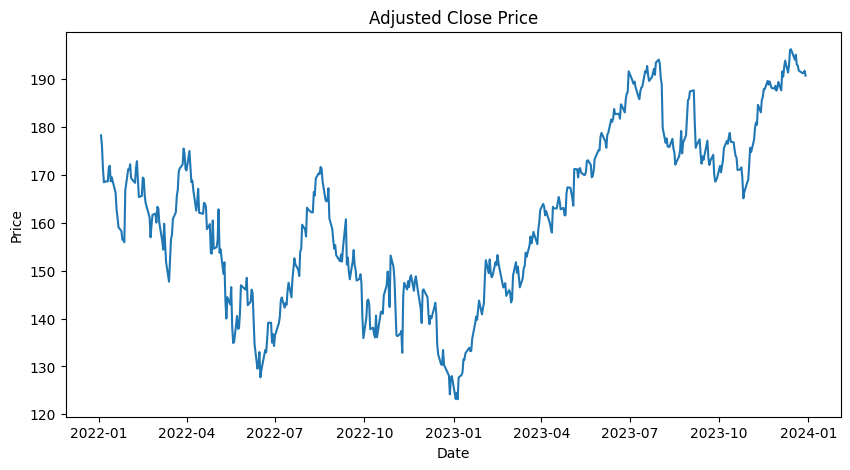

In [47]:
plt.plot(data.index, data['Adj Close'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Adjusted Close Price')
plt.show()

## 6. Rolling Means (Moving Averages)

In [49]:
data['MA_20'] = data['Adj Close'].squeeze().rolling(window=20).mean()
data['MA_50'] = data['Adj Close'].squeeze().rolling(window=50).mean()
data.head(25)

Price,Adj Close,Close,High,Low,Open,Volume,MA_20,MA_50
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,,
2022-01-03,178.270294,182.009995,182.880005,177.710007,177.830002,104487900,NaN,NaN
2022-01-04,176.007828,179.699997,182.940002,179.119995,182.630005,99310400,NaN,NaN
2022-01-05,171.326019,174.919998,180.169998,174.639999,179.610001,94537600,NaN,NaN
2022-01-06,168.465958,172.000000,175.300003,171.639999,172.699997,96904000,NaN,NaN
2022-01-07,168.632492,172.169998,174.139999,171.029999,172.889999,86709100,NaN,NaN
2022-01-10,168.652084,172.190002,172.500000,168.169998,169.080002,106765600,NaN,NaN
2022-01-11,171.482727,175.080002,175.179993,170.820007,172.320007,76138300,NaN,NaN
2022-01-12,171.923477,175.529999,177.179993,174.820007,176.119995,74805200,NaN,NaN


## 7. Price with Moving Averages

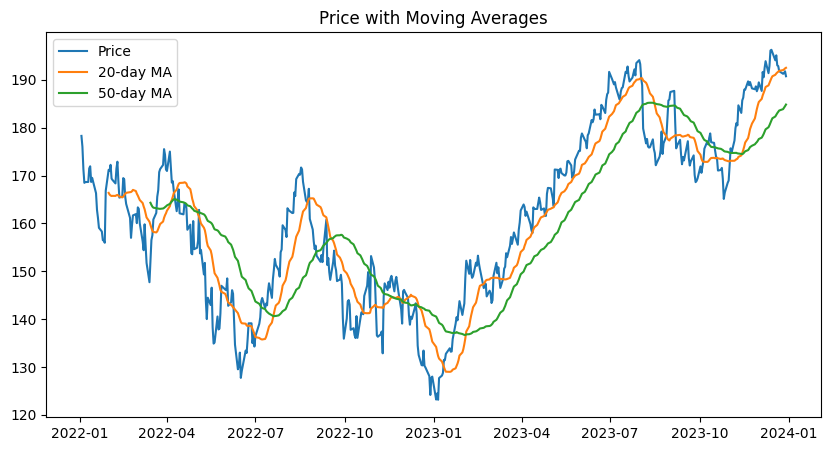

In [50]:
plt.plot(data.index, data['Adj Close'], label='Price')
plt.plot(data.index, data['MA_20'], label='20-day MA')
plt.plot(data.index, data['MA_50'], label='50-day MA')
plt.legend()
plt.title('Price with Moving Averages')
plt.show()

## 8. Daily Returns

In [51]:
data['Daily Return'] = data['Adj Close'].squeeze().pct_change()
data['Daily Return'].head()

Date
2022-01-03         NaN
2022-01-04   -0.012691
2022-01-05   -0.026600
2022-01-06   -0.016694
2022-01-07    0.000989
Name: Daily Return, dtype: float64

## 9. Visualizing Returns

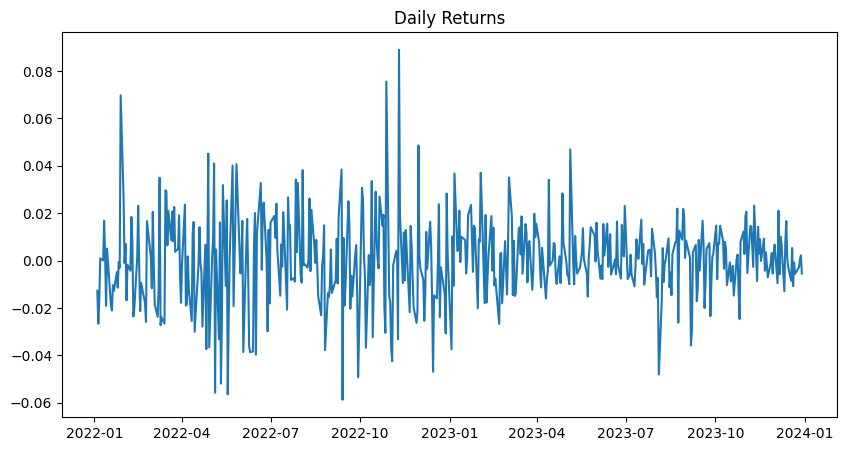

In [52]:
plt.plot(data.index, data['Daily Return'])
plt.title('Daily Returns')
plt.show()

## 10. Return Distribution

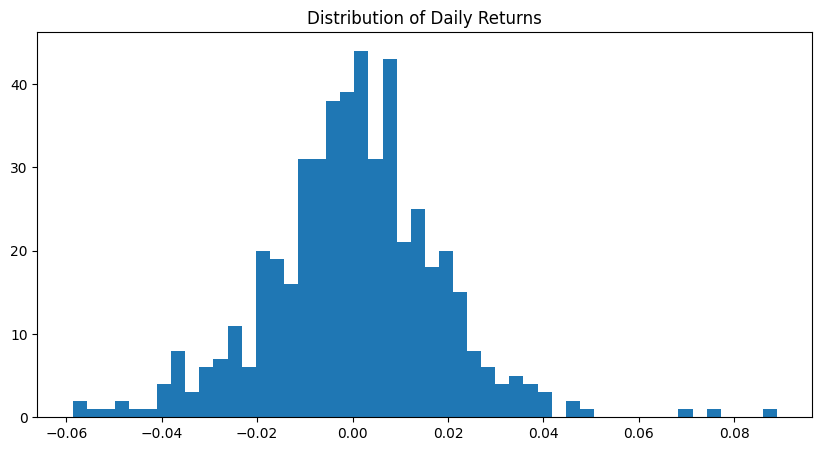

In [53]:
plt.hist(data['Daily Return'].dropna(), bins=50)
plt.title('Distribution of Daily Returns')
plt.show()

## 11. Simple Rule-Based Signal

In [56]:
data['Signal'] = (data['Adj Close'].squeeze() > data['MA_20'].squeeze()).astype(int)
data.loc[data['Signal'].squeeze() == 0, 'Signal'] = -1
data.loc[data['MA_20'].squeeze().isna(), 'Signal'] = 0
data.head(50)

Price,Adj Close,Close,High,Low,Open,Volume,MA_20,MA_50,Daily Return,Signal
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,,
2022-01-03,178.270294,182.009995,182.880005,177.710007,177.830002,104487900,NaN,NaN,NaN,0
2022-01-04,176.007828,179.699997,182.940002,179.119995,182.630005,99310400,NaN,NaN,-0.012691,0
2022-01-05,171.326019,174.919998,180.169998,174.639999,179.610001,94537600,NaN,NaN,-0.026600,0
2022-01-06,168.465958,172.000000,175.300003,171.639999,172.699997,96904000,NaN,NaN,-0.016694,0
2022-01-07,168.632492,172.169998,174.139999,171.029999,172.889999,86709100,NaN,NaN,0.000989,0
2022-01-10,168.652084,172.190002,172.500000,168.169998,169.080002,106765600,NaN,NaN,0.000116,0
2022-01-11,171.482727,175.080002,175.179993,170.820007,172.320007,76138300,NaN,NaN,0.016784,0
2022-01-12,171.923477,175.529999,177.179993,174.820007,176.119995,74805200,NaN,NaN,0.002570,0
